In [18]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!wget https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip

--2025-09-08 09:58:16--  https://bitbucket.org/ishaanjav/code-and-deploy-custom-tensorflow-lite-model/raw/a4febbfee178324b2083e322cdead7465d6fdf95/fruits.zip
Resolving bitbucket.org (bitbucket.org)... 13.200.41.134, 13.200.41.136, 13.200.41.135, ...
Connecting to bitbucket.org (bitbucket.org)|13.200.41.134|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 105946856 (101M) [application/zip]
Saving to: ‘fruits.zip’

fruits.zip          100%[===================>] 101.04M  17.1MB/s    in 6.9s    

2025-09-08 09:58:25 (14.7 MB/s) - ‘fruits.zip’ saved [105946856/105946856]



In [3]:
!unzip fruits.zip

Archive:  fruits.zip
   creating: fruits/
  inflating: __MACOSX/._fruits       
  inflating: fruits/.DS_Store        
  inflating: __MACOSX/fruits/._.DS_Store  
   creating: fruits/test/
   creating: fruits/train/
   creating: fruits/validation/
   creating: fruits/test/apple/
  inflating: fruits/test/.DS_Store   
  inflating: __MACOSX/fruits/test/._.DS_Store  
   creating: fruits/test/banana/
   creating: fruits/test/orange/
   creating: fruits/train/apple/
  inflating: fruits/train/.DS_Store  
  inflating: __MACOSX/fruits/train/._.DS_Store  
   creating: fruits/train/banana/
   creating: fruits/train/orange/
   creating: fruits/validation/apple/
  inflating: fruits/validation/.DS_Store  
  inflating: __MACOSX/fruits/validation/._.DS_Store  
   creating: fruits/validation/banana/
   creating: fruits/validation/orange/
  inflating: fruits/test/apple/Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflating: __MACOSX/fruits/test/apple/._Screen Shot 2018-06-08 at 5.27.19 PM.png  
  inflatin

In [4]:
import tensorflow as tf
import matplotlib.pyplot as plt


In [5]:
tf.__version__

'2.19.0'

In [8]:
img_height, img_width=32,32
batch_size=20

train_ds=tf.keras.utils.image_dataset_from_directory(
    'fruits/train',
    image_size=(img_height,img_width),
    batch_size=batch_size
)
val_ds=tf.keras.utils.image_dataset_from_directory(
    'fruits/validation',
    image_size=(img_height,img_width),
    batch_size=batch_size
)
test_ds=tf.keras.utils.image_dataset_from_directory(
    'fruits/test',
    image_size=(img_height,img_width),
    batch_size=batch_size
)

Found 460 files belonging to 3 classes.
Found 66 files belonging to 3 classes.
Found 130 files belonging to 3 classes.


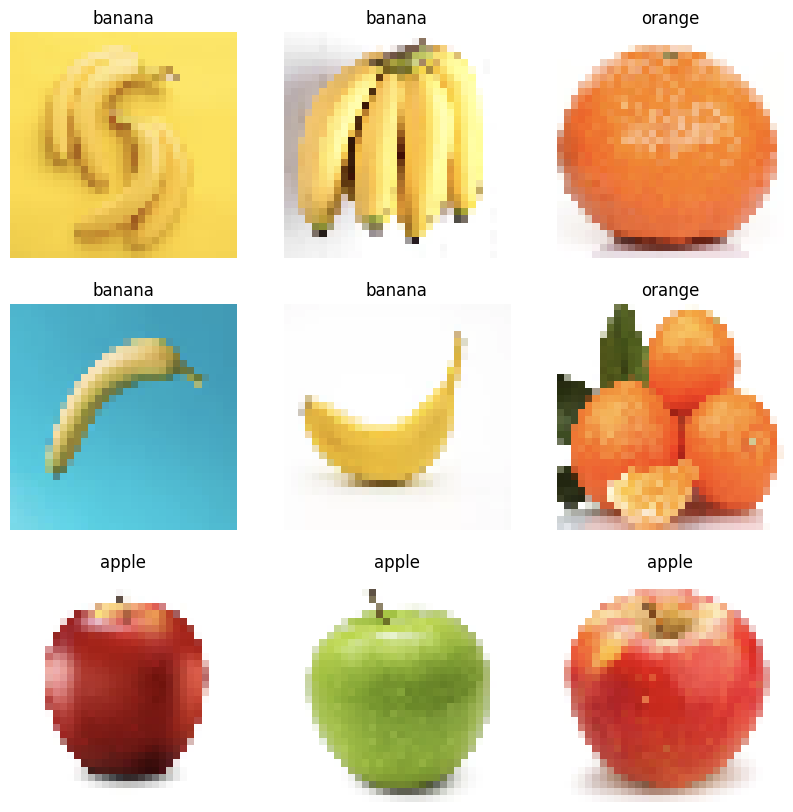

In [13]:
class_name=['apple', 'banana', 'orange']
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax=plt.subplot(3,3,i+1)
    plt.imshow(images[i].numpy().astype('uint8'))
    plt.title(class_name[labels[i]])
    plt.axis('off')

In [10]:
model = tf.keras.Sequential(
    [
     tf.keras.layers.Rescaling(1./255),
     tf.keras.layers.Conv2D(32, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(64, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Conv2D(128, 3, activation="relu"),
     tf.keras.layers.MaxPooling2D(),
     tf.keras.layers.Flatten(),
     tf.keras.layers.Dense(128, activation="softmax"),
     tf.keras.layers.Dense(3)
    ]
)

In [11]:
model.compile(
    optimizer="rmsprop",
    loss=tf.losses.SparseCategoricalCrossentropy(from_logits = True),
    metrics=['accuracy']
)

In [12]:
model.fit(
    train_ds,
    validation_data = val_ds,
    epochs = 20
)

Epoch 1/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 112ms/step - accuracy: 0.3764 - loss: 1.0983 - val_accuracy: 0.5758 - val_loss: 1.0957
Epoch 2/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 9s 185ms/step - accuracy: 0.3884 - loss: 1.0864 - val_accuracy: 0.5152 - val_loss: 1.0334
Epoch 3/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 62ms/step - accuracy: 0.5823 - loss: 1.0215 - val_accuracy: 0.6970 - val_loss: 0.9749
Epoch 4/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.6266 - loss: 0.9810 - val_accuracy: 0.6818 - val_loss: 0.9565
Epoch 5/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6391 - loss: 0.9762 - val_accuracy: 0.7424 - val_loss: 0.9303
Epoch 6/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.7172 - loss: 0.9355 - val_accuracy: 0.7727 - val_loss: 0.9072
Epoch 7/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 97ms/step - accuracy: 0.7814 - loss: 0.9125 - val_accuracy: 0.8182 - val_loss: 0.8804
Epoch 8/20
23/23 ━━━━━━━━━━━━━━━━━━━━ 2s 82ms/step - accuracy: 0.7926 - loss: 0.8937 - val_accuracy: 0.7121 -

In [14]:
model.evaluate(test_ds)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 163ms/step - accuracy: 0.9757 - loss: 0.5859


[0.6022354364395142, 0.9615384340286255]

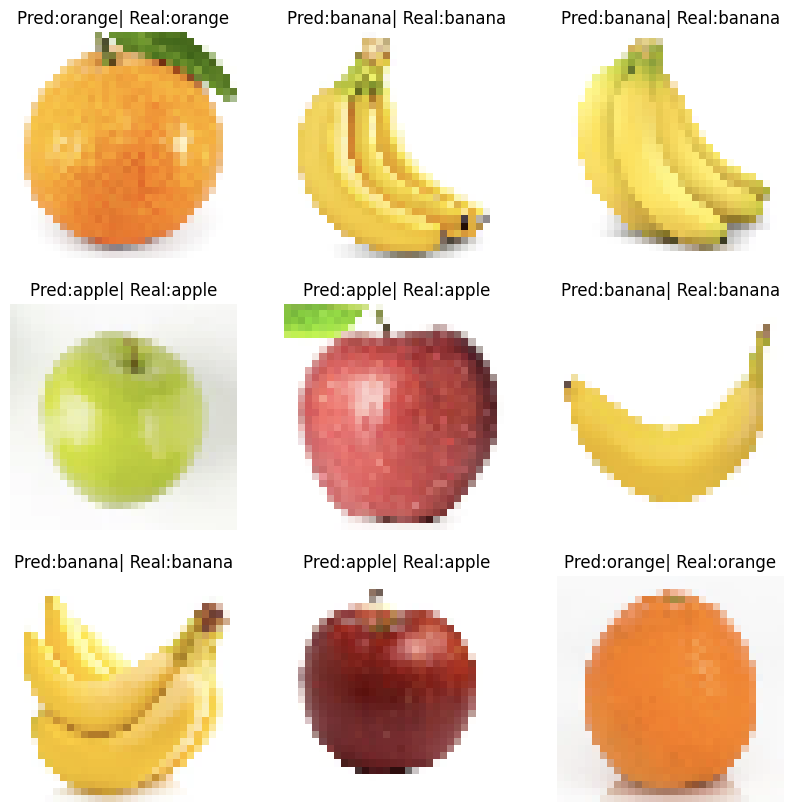

In [16]:
import numpy as np
plt.figure(figsize=(10,10))
for images, labels in test_ds.take(1):
  classifications=model(images)
  #print(classifications)

  for i in range(9):
      ax=plt.subplot(3,3,i+1)
      plt.imshow(images[i].numpy().astype('uint8'))
      index=np.argmax(classifications[i])
      plt.title('Pred:' + class_name [index]+ '| Real:' + class_name[labels[i]])
      plt.axis('off')

In [17]:
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open("model.tflite", 'wb') as f:
  f.write(tflite_model)

Saved artifact at '/tmp/tmpxzaq84bu'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 32, 32, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 3), dtype=tf.float32, name=None)
Captures:
  134034385940560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385943248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385943440: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385944400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385944016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385944208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134033822285904: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134033822287248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134034385937680: TensorSpec(shape=(), dtype=tf.resource, name=None)
  134033822288208: TensorSpec(shape=(), dtype=tf.resource, name=None)
